# Part two — Understanding: recover the hidden variables 🧪

**Goal.** The use-case itself: an AI *understanding* a physical system — a world model
recovering the hidden state (the concentrations) from raw sensors, graded against a known
key. And the practical question that decides tool choice everywhere: when is simple PCA
enough, and when is a learned encoder the only reader that works?

*Companion notebook to **A Window into World Models: The Next Generation of AI**. Everything is generated inside this notebook. Four simulated measurement systems
(inspired by real technologies) where every hidden concentration is known in advance: we
hide the truth, hand each method only the ten sensors, and grade the reconstruction against
the key. No dataset is read from disk. Runs top-to-bottom on Google Colab (the trained-encoder cell takes a few minutes on CPU).*

Two data-measurable questions place each system on the paper's grid, and they point at
**different things**:

* **Is it linear?** — a property of the *sensors* (how a reading depends on the hidden state);
* **Is it Gaussian?** — a property of the *hidden variables* themselves.


In [1]:
# Colab's standard runtime has everything: numpy, scipy, scikit-learn, matplotlib
import warnings; warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "font.size": 9,
                     "axes.spines.top": False, "axes.spines.right": False})
BLUE, GREEN, RED, MID, GREY = "#3d6fb4", "#1a7f37", "#b3261e", "#8a6d1a", "#8a91a0"
import pandas as pd
from pathlib import Path
OUT = Path("generated_data_part2")
OUT.mkdir(exist_ok=True)
print("Generated files will be written to:", OUT.resolve())


Generated files will be written to: /sessions/trusting-intelligent-franklin/mnt/outputs/nbrun/generated_data_part2


## 1 · One world, four disguises

All four systems share the same skeleton — hidden variables drifting on a slow, stationary
AR(1) (40-minute memory, sampled every 30 s, 24 000 samples), read by ten noisy sensors.
The **only** differences are (a) the marginal shape of the hidden variables and (b) whether
the sensor laws are straight. `make_driver` produces either a Gaussian driver or a
lognormal one (Gaussian in the log — same time structure, heavy-tailed marginal).

In [2]:
import numpy as np, json
from scipy.stats import kurtosis, skew

# ------------------------------------------------------------------ common
N_SAMP = 24000
DT_MIN = 0.5                      # 30 s
TAU_MIN = 40.0                    # vessel / hopper turnover
LAG = 10                          # alignment lag = 5 min
RHO = float(np.exp(-DT_MIN / TAU_MIN))
RHO_LAG = float(RHO ** LAG)
NOISE_FRAC = 0.004
Q = 4
SEED = 20260801


def ar1_gauss(n, rho, seed):
    """Unit-variance stationary Gaussian AR(1)."""
    rs = np.random.RandomState(seed)
    e = rs.randn(n + 3000)
    x = np.zeros(n + 3000)
    s = np.sqrt(1.0 - rho ** 2)
    for t in range(1, n + 3000):
        x[t] = rho * x[t - 1] + s * e[t]
    x = x[3000:]
    return (x - x.mean()) / x.std()


def make_driver(n, rho, seed, spec):
    """spec = (shape, a, b).
    gauss     -> a + b*z            (a = mean, b = sd)
    lognorm   -> a * exp(b*z)       (a = median, b = sigma of the log)
    Both keep the AR(1) time structure exactly; lognorm is Gaussian in log.
    """
    shape, a, b = spec
    z = ar1_gauss(n, rho, seed)
    if shape == "gauss":
        return a + b * z
    if shape == "lognorm":
        return a * np.exp(b * z)
    raise ValueError(shape)

### System ① — tablet press (linear · Gaussian)
Ten NIR wavelengths over a flowing powder blend. Beer–Lambert: every absorbance is a plain
weighted **sum** of the four component amounts (API, lactose, stearate, moisture), which are
dosed to targets → tidy Gaussian bells.

In [3]:
# ============================================================== SYSTEM 1
# Tablet press, near-infrared at ten wavelengths. Strictly Beer-Lambert:
# every channel is a weighted SUM of the four component masses. Absorbances
# are kept low so there is no stray-light or path saturation anywhere.
S1_DRV = ["API", "Lactose", "Stearate", "Moisture"]
S1_UNITS = {"API": "mg/tab", "Lactose": "mg/tab", "Stearate": "mg/tab",
            "Moisture": "mg/tab"}
# Content uniformity of a well-mixed blend is Normal by the central limit
# theorem; USP content-uniformity limits are built on that assumption.
S1_SPEC = {"API": ("gauss", 325.0, 8.0),          # 2.5% RSD
           "Lactose": ("gauss", 140.0, 6.0),
           "Stearate": ("gauss", 5.00, 0.45),
           "Moisture": ("gauss", 12.0, 1.10)}
S1_CHAN = ["A1150", "A1350", "A1450", "A1580", "A1680",
           "A1780", "A1940", "A2050", "A2140", "A2260"]
# absorptivity, milli-AU per mg. Rows = wavelength, cols = component.
# API: aromatic CH near 1680 and 2140. Lactose: OH/CH 1580, 2050, 2260.
# Stearate: long-chain CH2 near 1780. Moisture: OH bands 1450 and 1940.
S1_E = np.array([
    [0.62, 0.55, 0.30, 0.44],   # 1150
    [0.71, 0.68, 0.42, 0.86],   # 1350
    [0.48, 0.61, 0.25, 6.40],   # 1450  water
    [0.94, 1.62, 0.36, 1.05],   # 1580  lactose
    [2.05, 0.74, 0.58, 0.62],   # 1680  API
    [0.66, 0.59, 3.10, 0.51],   # 1780  stearate
    [0.52, 0.70, 0.28, 8.90],   # 1940  water
    [1.08, 1.85, 0.61, 1.24],   # 2050  lactose
    [2.34, 0.96, 0.72, 0.68],   # 2140  API
    [0.88, 1.71, 0.95, 0.79],   # 2260  lactose
]) / 1000.0
S1_BASE = np.array([0.041, 0.048, 0.052, 0.058, 0.063,
                    0.067, 0.072, 0.078, 0.082, 0.089])


def s1_channels(API, Lactose, Stearate, Moisture):
    c = np.array([np.asarray(API, float), np.asarray(Lactose, float),
                  np.asarray(Stearate, float), np.asarray(Moisture, float)])
    A = S1_E @ c + S1_BASE[:, None]
    return {n: A[i] for i, n in enumerate(S1_CHAN)}

### System ② — two-sugar saccharimeter (nonlinear · Gaussian)
Each sugar rotates polarized light in proportion to its concentration (Biot's law); every
detector reads `cos²(α − θ)` (Malus's law) at five wavelengths × two analyser angles. At
this concentration and path the rotation sweeps ~1.55π, so the readings **wrap** — a fold.
The two concentrations themselves stay Gaussian.

In [4]:
# ============================================================== SYSTEM 2
# Two-sugar saccharimeter (polarimeter). Gaussian driver concentrations, but a
# STRONGLY nonlinear instrument: each optically active sugar rotates polarized
# light by an angle proportional to its concentration (Biot's law), and every
# detector reads intensity through a fixed analyzer by Malus's law,
# I = cos^2(alpha - theta). At high concentration / long path the rotation runs
# past 180 deg and the reading WRAPS -- a spiral. Sucrose and fructose are
# separable only because their rotatory-dispersion curves differ (distinct
# Drude constants), so five wavelengths span a 2-D space. No linear method can
# unwrap an angle; a trained encoder can.
S2_DRV = ["Sucrose", "Fructose"]
S2_UNITS = {"Sucrose": "g/100mL", "Fructose": "g/100mL"}
S2_SPEC = {"Sucrose": ("gauss", 32.0, 5.0),
           "Fructose": ("gauss", 24.0, 4.0)}
# ten detectors = five wavelengths x two analyzer angles (0 deg, 45 deg)
S2_WL = ["436", "546", "578", "589", "633"]
S2_CHAN = [f"P{w}{a}" for w in S2_WL for a in ("a", "b")]
S2_UN = {c: "rel" for c in S2_CHAN}
# specific rotation with one-term Drude dispersion; sucrose +66.5, fructose -92
_S2_LAM = np.array([0.436, 0.546, 0.578, 0.589, 0.633])   # micron
_S2_DS = 1.0 / (_S2_LAM ** 2 - 0.150 ** 2); _S2_DS /= _S2_DS[3]
_S2_DF = 1.0 / (_S2_LAM ** 2 - 0.205 ** 2); _S2_DF /= _S2_DF[3]
_S2_AS = 66.5 * _S2_DS                # sucrose: positive at every wavelength
_S2_AF = -92.0 * _S2_DF               # fructose: negative at every wavelength
_S2_SPAN = 1.55 * np.pi               # how far the strongest reading sweeps
_S2_MU = {"Sucrose": 32.0, "Fructose": 24.0}
_S2_SD = {"Sucrose": 5.0, "Fructose": 4.0}


def s2_channels(Sucrose, Fructose):
    # standardise with FIXED design constants (single-point safe)
    zS = (np.asarray(Sucrose, float) - _S2_MU["Sucrose"]) / _S2_SD["Sucrose"]
    zF = (np.asarray(Fructose, float) - _S2_MU["Fructose"]) / _S2_SD["Fructose"]
    out = {}
    for j, w in enumerate(S2_WL):
        alpha = _S2_SPAN * (_S2_AS[j] * zS + _S2_AF[j] * zF) / 220.0
        out[f"P{w}a"] = np.cos(alpha) ** 2               # analyzer at 0 deg
        out[f"P{w}b"] = np.cos(alpha - np.pi / 4) ** 2   # analyzer at 45 deg
    return out

### System ③ — river-water metals, ICP-OES (linear · non-Gaussian)
Emission counts proportional to concentration — clean straight lines. But trace metals sit
near a low background and *multiply* during plumes: lognormal, heavily skewed.

In [5]:
# ============================================================== SYSTEM 3
# ICP-OES on river water. Trace element concentrations in natural waters are
# log-normal (Ahrens). Emission intensity is LINEAR in concentration over
# several decades, and interelement overlap is additive -- which is exactly
# why instruments correct it with a linear IEC matrix.
S3_DRV = ["Fe", "Mn", "Zn", "Ca"]
S3_UNITS = {k: "mg/L" for k in S3_DRV}
S3_SPEC = {"Fe": ("lognorm", 0.450, 0.875),      # GSD 2.4
           "Mn": ("lognorm", 0.085, 0.955),      # GSD 2.6
           "Zn": ("lognorm", 0.030, 0.788),      # GSD 2.2
           "Ca": ("lognorm", 42.0, 0.300)}       # major ion, tighter
S3_CHAN = ["Fe238", "Fe259", "Mn257", "Mn293", "Zn213",
           "Zn206", "Ca393", "Ca317", "Mn403", "Fe234"]
# sensitivity, kilocounts per mg/L. The Zn 213.856 row carries a real Fe
# contribution: Fe 213.859 sits directly on it.
S3_S = np.array([
    [64.0,  0.35, 0.10, 0.02],   # Fe 238.204
    [51.0,  0.28, 0.08, 0.03],   # Fe 259.940
    [1.90, 88.0,  0.12, 0.05],   # Mn 257.610  (Fe wing)
    [0.40, 42.0,  0.06, 0.02],   # Mn 293.306
    [7.30,  0.22, 96.0, 0.04],   # Zn 213.856  <- Fe 213.859 overlap
    [0.55,  0.10, 38.0, 0.02],   # Zn 206.200
    [0.06,  0.04, 0.03, 21.0],   # Ca 393.366
    [0.09,  0.05, 0.02, 8.40],   # Ca 317.933
    [0.31, 26.0,  0.05, 0.34],   # Mn 403.076
    [46.0,  0.24, 0.09, 0.02],   # Fe 234.350
])
S3_BG = np.array([1.20, 1.05, 0.98, 0.86, 1.32,
                  0.91, 2.40, 1.75, 0.79, 1.14])


def s3_channels(Fe, Mn, Zn, Ca):
    c = np.array([np.asarray(Fe, float), np.asarray(Mn, float),
                  np.asarray(Zn, float), np.asarray(Ca, float)])
    I = S3_S @ c + S3_BG[:, None]
    return {n: I[i] for i, n in enumerate(S3_CHAN)}

### System ④ — anaerobic digester (nonlinear · non-Gaussian)
Haldane/Andrews inhibition: biogas **rises then falls** as volatile acids climb — a fold —
and the acids themselves spike lognormally under slug loads.

In [6]:
# ============================================================== SYSTEM 4
# Anaerobic digester on slug loads. Log-normal drivers AND saturating,
# folding sensors. Biogas follows Haldane-Andrews: it rises with VFA, peaks,
# then falls as the acids inhibit the methanogens.
S4_DRV = ["VFA", "Alkalinity", "Ammonia", "Biomass"]
S4_UNITS = {"VFA": "mg/L HAc", "Alkalinity": "mg/L CaCO3",
            "Ammonia": "mg/L N", "Biomass": "g/L VSS"}
S4_SPEC = {"VFA": ("lognorm", 320.0, 0.875),      # slug loads
           "Alkalinity": ("lognorm", 2800.0, 0.300),
           "Ammonia": ("lognorm", 1150.0, 0.400),
           "Biomass": ("lognorm", 12.0, 0.250)}
S4_CHAN = ["Biogas", "CH4", "CO2gas", "pH", "ORP",
           "Cond", "Turb", "NH4ISE", "AlkTit", "TOC"]
S4_UN = {"Biogas": "m3/h", "CH4": "%", "CO2gas": "%", "pH": "-", "ORP": "mV",
         "Cond": "mS/cm", "Turb": "NTU", "NH4ISE": "V", "AlkTit": "mL",
         "TOC": "mg/L"}
KS_VFA = 210.0     # half-saturation, mg/L as HAc
KI_VFA = 480.0     # Haldane-Andrews inhibition constant, mg/L as HAc
KA_HAC = 1.74e-5   # acetic acid dissociation constant


def s4_channels(VFA, Alkalinity, Ammonia, Biomass):
    F = np.asarray(VFA, float); A = np.asarray(Alkalinity, float)
    M = np.asarray(Ammonia, float); B = np.asarray(Biomass, float)
    out = {}
    # Haldane-Andrews: rises, peaks, then falls. THE FOLD.
    andrews = F / (KS_VFA + F + F ** 2 / KI_VFA)
    inhib_nh3 = 1.0 / (1.0 + (M / 2600.0) ** 2)      # free-ammonia inhibition
    out["Biogas"] = 34.0 * B * andrews * inhib_nh3
    # methane fraction falls as acids build
    out["CH4"] = 72.0 / (1.0 + 0.00042 * F) - 0.00055 * M
    out["CO2gas"] = 96.0 - out["CH4"] - 0.0022 * M
    # carbonate/acetate equilibrium: a square-root law
    cA = A / 50.04 * 1e-3                            # eq/L as CaCO3
    cF = F / 60.05 * 1e-3                            # mol/L HAc
    H = 0.5 * (-(KA_HAC + cA) + np.sqrt((KA_HAC + cA) ** 2
                                        + 4.0 * KA_HAC * cF))
    out["pH"] = -np.log10(np.clip(H, 1e-12, None))
    out["ORP"] = -285.0 + 26.0 * np.log10(F / 320.0 + 0.05) - 0.011 * M
    out["Cond"] = (0.92 + 1.85e-3 * A + 2.60e-3 * M + 0.95e-3 * F
                   - 4.2e-8 * (A + M + F) ** 1.5)
    out["Turb"] = 640.0 * (1.0 - np.exp(-(0.145 * B + 2.4e-4 * F) / 1.55))
    out["NH4ISE"] = 0.0620 + 0.05916 * np.log10(M / 14.007 * 1e-3 + 8e-5)
    out["AlkTit"] = 0.0105 * A + 0.0038 * F + 0.9
    out["TOC"] = 1850.0 * (1.0 - np.exp(-(0.42 * F + 18.0 * B) / 2100.0))
    return out

In [7]:
SYS = {
    "S1_tablet": dict(
        cell="Gaussian + linear", grid=(0, 0),
        title="Tablet press, NIR at ten wavelengths",
        drv=S1_DRV, units=S1_UNITS, spec=S1_SPEC,
        chan=S1_CHAN, cunits={c: "AU" for c in S1_CHAN}, fn=s1_channels),
    "S2_saccharimeter": dict(
        cell="Gaussian + nonlinear", grid=(0, 1),
        title="Two-sugar saccharimeter, ten polarimetric detectors",
        drv=S2_DRV, units=S2_UNITS, spec=S2_SPEC,
        chan=S2_CHAN, cunits=S2_UN, fn=s2_channels),
    "S3_icp": dict(
        cell="not Gaussian + linear", grid=(1, 0),
        title="ICP-OES on river water, ten emission lines",
        drv=S3_DRV, units=S3_UNITS, spec=S3_SPEC,
        chan=S3_CHAN, cunits={c: "kcounts" for c in S3_CHAN}, fn=s3_channels),
    "S4_digester": dict(
        cell="not Gaussian + nonlinear", grid=(1, 1),
        title="Anaerobic digester on slug loads, ten probes",
        drv=S4_DRV, units=S4_UNITS, spec=S4_SPEC,
        chan=S4_CHAN, cunits=S4_UN, fn=s4_channels),
}


def simulate(key, n=N_SAMP, logdrv=False):
    s = SYS[key]
    drv = {}
    for i, k in enumerate(s["drv"]):
        drv[k] = make_driver(n, RHO, SEED + 137 * i + 7 * len(key), s["spec"][k])
    clean = s["fn"](*[drv[k] for k in s["drv"]])
    rs = np.random.RandomState(SEED + 9091)
    noise, noisy = {}, {}
    for c in s["chan"]:
        v = np.asarray(clean[c], float)
        e = NOISE_FRAC * (v.max() - v.min()) * rs.randn(n)
        noise[c] = e
        noisy[c] = v + e
    target = ({f"log {k}": np.log(drv[k]) for k in s["drv"]} if logdrv
              else {k: drv[k] for k in s["drv"]})
    return drv, clean, noise, noisy, target

## 2 · The readers, and the score

`pca_dirs` keeps the directions of greatest variance (straight sums of the sensors — never
sees time). `lejepa_dirs` is the *linear* LeJEPA reading: whiten (the round-cloud rule),
then keep the **slowest** whitened directions (the alignment rule). `score` is a linear
read-out onto the true variables on held-out data — *linear-probe decodability*, R² of the
worst hidden variable. `straightness` and `gaussianity` are the two data-measured checks.

In [8]:
def split(n, frac=0.75):
    cut = int(n * frac)
    return np.arange(cut), np.arange(cut, n)


def standardise(X, tr):
    mu, sd = X[tr].mean(0), X[tr].std(0)
    sd[sd == 0] = 1.0
    return (X - mu) / sd


def pca_dirs(Z, tr, q):
    C = np.cov(Z[tr].T)
    w, V = np.linalg.eigh(C)
    o = np.argsort(w)[::-1]
    return V[:, o[:q]], w[o]


def lejepa_dirs(Z, tr, q, lag=LAG):
    """Isotropy (whiten) + alignment (keep the slowest)."""
    C = np.cov(Z[tr].T)
    w, V = np.linalg.eigh(C)
    w = np.clip(w, 1e-12, None)
    Wh = V @ np.diag(w ** -0.5) @ V.T
    Y = Z @ Wh
    dY = Y[tr][lag:] - Y[tr][:-lag]
    D = np.cov(dY.T)
    wd, Vd = np.linalg.eigh(D)
    o = np.argsort(wd)
    return Wh @ Vd[:, o[:q]], wd[o]


def score(F, Y, tr, te):
    A = np.c_[F[tr], np.ones(len(tr))]
    coef, *_ = np.linalg.lstsq(A, Y[tr], rcond=None)
    P = np.c_[F[te], np.ones(len(te))] @ coef
    out = []
    for j in range(Y.shape[1]):
        ss = ((Y[te, j] - P[:, j]) ** 2).sum()
        tt = ((Y[te, j] - Y[te, j].mean()) ** 2).sum()
        out.append(1.0 - ss / tt)
    return np.array(out)


def straightness(key, sim=None):
    """Linearity axis: R2 of a straight line in the four drivers, per channel.
    Computed on the NOISELESS laws, so it measures the law and not the noise."""
    s = SYS[key]
    if sim is None:
        sim = simulate(key)
    drv, clean, _, _, _ = sim
    M = np.column_stack([drv[k] for k in s["drv"]] + [np.ones(len(drv[s["drv"][0]]))])
    out = {}
    for c in s["chan"]:
        y = np.asarray(clean[c], float)
        b, *_ = np.linalg.lstsq(M, y, rcond=None)
        p = M @ b
        out[c] = float(1.0 - ((y - p) ** 2).sum() / ((y - y.mean()) ** 2).sum())
    return out


def gaussianity(key, sim=None):
    """Gaussianity axis: skew and excess kurtosis of each driver's marginal."""
    s = SYS[key]
    if sim is None:
        sim = simulate(key)
    drv = sim[0]
    return {k: dict(skew=float(skew(drv[k])),
                    kurt=float(kurtosis(drv[k])),
                    ratio=float(drv[k].max() / drv[k].min()))
            for k in s["drv"]}


def run(key, q=Q, logdrv=False, sim=None):
    s = SYS[key]
    if sim is None:
        sim = simulate(key, logdrv=logdrv)
    drv, clean, noise, noisy, target = sim
    X = np.column_stack([noisy[c] for c in s["chan"]])
    tkeys = list(target.keys())
    Y = np.column_stack([target[k] for k in tkeys])
    assert np.isfinite(X).all(), f"{key}: non-finite reading"
    tr, te = split(len(X))
    Z = standardise(X, tr)
    Vp, evp = pca_dirs(Z, tr, q)
    Vl, evl = lejepa_dirs(Z, tr, q)
    r2p, r2l = score(Z @ Vp, Y, tr, te), score(Z @ Vl, Y, tr, te)
    st = straightness(key, sim=(drv, clean, noise, noisy, target))
    gs = gaussianity(key, sim=(drv, clean, noise, noisy, target))
    return dict(
        key=key, cell=s["cell"], title=s["title"], grid=s["grid"],
        q=q, logdrv=logdrv, n=len(X), n_test=len(te),
        drivers=tkeys,
        pca_r2={k: float(v) for k, v in zip(tkeys, r2p)},
        lejepa_r2={k: float(v) for k, v in zip(tkeys, r2l)},
        pca_overall=float(r2p.mean()), lejepa_overall=float(r2l.mean()),
        pca_worst=float(r2p.min()), lejepa_worst=float(r2l.min()),
        scree=[float(v / evp.sum() * 100) for v in evp],
        align=[float(v) for v in evl],
        align_rho=[float(1.0 - v / 2.0) for v in evl],
        straight=st,
        straight_mean=float(np.mean(list(st.values()))),
        straight_worst=float(min(st.values())),
        straight_worst_chan=min(st, key=st.get),
        gauss=gs,
        max_abs_skew=float(max(abs(g["skew"]) for g in gs.values())),
        max_kurt=float(max(g["kurt"] for g in gs.values())),
        driver_stats={k: dict(min=float(drv[k].min()), med=float(np.median(drv[k])),
                              max=float(drv[k].max()),
                              ratio=float(drv[k].max() / drv[k].min()))
                      for k in s["drv"]},
        chan_stats={c: dict(min=float(noisy[c].min()), max=float(noisy[c].max()),
                            unit=s["cunits"][c]) for c in s["chan"]},
    )

In [9]:
import json
KEYS = ["S1_tablet", "S2_saccharimeter", "S3_icp", "S4_digester"]
SIMS = {k: simulate(k) for k in KEYS}
RES  = {k: run(k, sim=SIMS[k]) for k in KEYS}
print(f"{'system':22s} {'corner':24s} {'straight':>9s} {'|skew|':>7s} {'PCA':>7s} {'linear-LeJEPA':>14s}")
for k in KEYS:
    r = RES[k]
    print(f"{r['title'][:22]:22s} {r['cell']:24s} {r['straight_worst']:9.4f} "
          f"{r['max_abs_skew']:7.2f} {r['pca_worst']:7.3f} {r['lejepa_worst']:14.3f}")

system                 corner                    straight  |skew|     PCA  linear-LeJEPA
Tablet press, NIR at t Gaussian + linear           1.0000    0.06   0.980          0.980
Two-sugar saccharimete Gaussian + nonlinear        0.0001    0.09  -0.093         -0.094
ICP-OES on river water not Gaussian + linear       1.0000    5.95   0.993          0.993
Anaerobic digester on  not Gaussian + nonlinear    0.7236    3.50   0.917          0.712


Read the table: the two **linear** systems are recovered almost perfectly by both linear
readers, *including* the wildly non-Gaussian metals — being non-Gaussian costs a linear
method nothing. The saccharimeter defeats **both** (a straight sum cannot unwrap an angle),
and the digester's fold drags both down. So far no method has beaten PCA anywhere — the
interesting move comes in §5, where the encoder is allowed to *bend*.

### The extracted sensor laws

For each system we fit every sensor as a **linear function of the hidden variables** and
write the equation out. For systems ① and ③ these fitted lines essentially *are* the
generating laws (R² ≈ 1: Beer–Lambert weights, emission slopes). For systems ② and ④ the
low R² is the nonlinearity, measured — the part no linear formula can express. All
coefficients are saved to `generated_data_part2/sensor_linear_fits.csv`.

In [10]:
rows=[]
for key in KEYS:
    drv, clean, noise, noisy, target = SIMS[key]; s=SYS[key]
    H=np.column_stack([drv[d] for d in s["drv"]]); M=np.c_[H, np.ones(len(H))]
    print(f"\n== {RES[key]['title']}  [{RES[key]['cell']}] ==")
    for ch in s["chan"]:
        y=np.asarray(noisy[ch],float)
        beta,*_=np.linalg.lstsq(M,y,rcond=None)
        p=M@beta; r2v=1-((y-p)**2).sum()/((y-y.mean())**2).sum()
        terms=" ".join(f"{bb:+.3g}*{d}" for bb,d in zip(beta[:-1], s["drv"]))
        print(f"  {ch:9s} ~ {terms} {beta[-1]:+.4g}      R^2 = {r2v:.3f}")
        row=dict(system=key, sensor=ch, R2=round(float(r2v),4),
                 intercept=round(float(beta[-1]),5))
        row.update({f"a_{d}":round(float(bb),5) for bb,d in zip(beta[:-1],s["drv"])})
        rows.append(row)
pd.DataFrame(rows).to_csv(OUT/"sensor_linear_fits.csv", index=False)
print("\nsaved:", OUT/"sensor_linear_fits.csv")


== Tablet press, NIR at ten wavelengths  [Gaussian + linear] ==
  A1150     ~ +0.00062*API +0.00055*Lactose +0.0003*Stearate +0.000439*Moisture +0.04097      R^2 = 0.999
  A1350     ~ +0.00071*API +0.00068*Lactose +0.00042*Stearate +0.000859*Moisture +0.04803      R^2 = 0.999
  A1450     ~ +0.00048*API +0.00061*Lactose +0.000246*Stearate +0.0064*Moisture +0.05211      R^2 = 0.999
  A1580     ~ +0.00094*API +0.00162*Lactose +0.000358*Stearate +0.00105*Moisture +0.058      R^2 = 0.999
  A1680     ~ +0.00205*API +0.00074*Lactose +0.000582*Stearate +0.000622*Moisture +0.06287      R^2 = 0.999
  A1780     ~ +0.00066*API +0.00059*Lactose +0.0031*Stearate +0.000511*Moisture +0.06698      R^2 = 0.999
  A1940     ~ +0.00052*API +0.0007*Lactose +0.000273*Stearate +0.0089*Moisture +0.07204      R^2 = 0.999
  A2050     ~ +0.00108*API +0.00185*Lactose +0.000611*Stearate +0.00123*Moisture +0.07799      R^2 = 0.999
  A2140     ~ +0.00234*API +0.000961*Lactose +0.000729*Stearate +0.000674*Moisture +0

### The generated datasets

Before going further, save transparent copies of the four worlds we just created. Each CSV contains the hidden variables (the answer key) and the ten noisy sensor readings. These files are **created here**; nothing below depends on a pre-existing data folder.


In [11]:
# Export each world exactly as generated here: time, hidden variables, and noisy sensors.
# The analysis below uses the in-memory objects; the CSVs are just transparent copies.
for key in KEYS:
    drv, clean, noise, noisy, target = SIMS[key]
    frame = {"time_min": np.arange(len(next(iter(drv.values())))) * DT_MIN}
    frame.update({f"hidden_{k}": np.asarray(v) for k, v in drv.items()})
    frame.update({f"sensor_{k}": np.asarray(v) for k, v in noisy.items()})
    path = OUT / f"{key}.csv"
    pd.DataFrame(frame).to_csv(path, index=False)
    print("saved:", path)

summary = pd.DataFrame([{k: v for k, v in RES[key].items()
                         if k in ["key", "cell", "title", "straight_worst", "max_abs_skew",
                                  "pca_worst", "lejepa_worst"]}
                        for key in KEYS])
summary.to_csv(OUT / "recovery_summary.csv", index=False)
display(summary)


saved: generated_data_part2/S1_tablet.csv


saved: generated_data_part2/S2_saccharimeter.csv


saved: generated_data_part2/S3_icp.csv


saved: generated_data_part2/S4_digester.csv


,key,cell,title,pca_worst,lejepa_worst,straight_worst,max_abs_skew
0,S1_tablet,Gaussian + linear,"Tablet press, NIR at ten wavelengths",0.979738,0.979707,1.000000,0.060632
1,S2_saccharimeter,Gaussian + nonlinear,"Two-sugar saccharimeter, ten polarimetric dete...",-0.092909,-0.094482,0.000054,0.087184
2,S3_icp,not Gaussian + linear,"ICP-OES on river water, ten emission lines",0.992552,0.993280,1.000000,5.948655
3,S4_digester,not Gaussian + nonlinear,"Anaerobic digester on slug loads, ten probes",0.917069,0.711747,0.723591,3.498292


## 3 · Check one, seen: is the sensor straight?

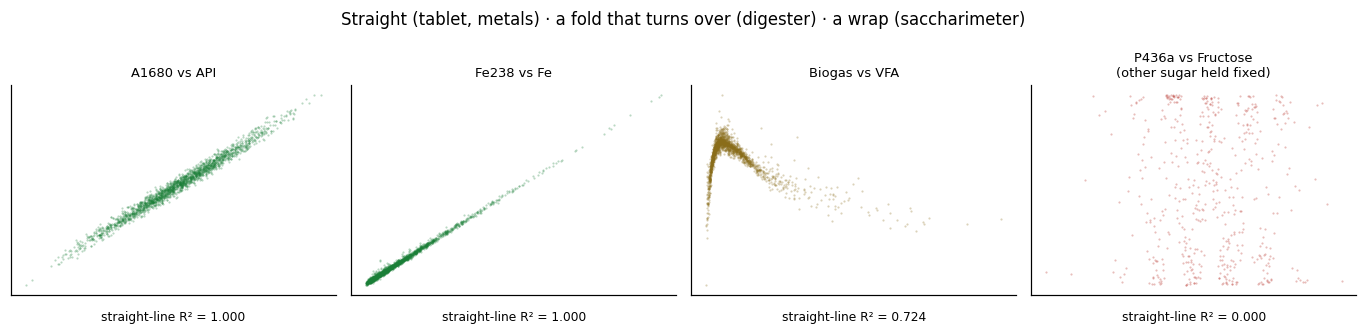

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(12.5, 3.1))
picks = [("S1_tablet", "A1680", "API"), ("S3_icp", "Fe238", "Fe"),
         ("S4_digester", "Biogas", "VFA"), ("S2_saccharimeter", "P436a", "Fructose")]
for ax, (k, ch, drv_name) in zip(axes, picks):
    drv, clean, _, noisy, _ = SIMS[k]
    s = SYS[k]
    if k == "S2_saccharimeter":                       # hold the OTHER sugar fixed
        other = [d for d in s["drv"] if d != drv_name][0]
        keep = np.abs(drv[other] - np.median(drv[other])) < .25 * drv[other].std()
        x, y = drv[drv_name][keep], np.asarray(noisy[ch])[keep]
        o = np.argsort(x); x, y = x[o], y[o]
        ax.scatter(x[::9], y[::9], s=2, alpha=.3, color=RED, lw=0)
        ax.set_title(f"{ch} vs {drv_name}\n(other sugar held fixed)", fontsize=8.5)
    else:
        others = [d for d in s["drv"] if d != drv_name]
        M = np.column_stack([drv[d] for d in others] + [np.ones(N_SAMP)])
        beta, *_ = np.linalg.lstsq(M, np.asarray(noisy[ch], float), rcond=None)
        resid = np.asarray(noisy[ch], float) - M @ beta
        x = drv[drv_name]
        col = GREEN if RES[k]["straight"][ch] > .99 else MID
        ax.scatter(x[::12], resid[::12], s=2, alpha=.3, color=col, lw=0)
        ax.set_title(f"{ch} vs {drv_name}", fontsize=8.5)
    ax.set_xticks([]); ax.set_yticks([])
    ax.text(.5, -.12, f"straight-line R² = {RES[k]['straight'][ch]:.3f}",
            transform=ax.transAxes, ha="center", fontsize=8)
fig.suptitle("Straight (tablet, metals) · a fold that turns over (digester) · a wrap (saccharimeter)")
fig.tight_layout(); plt.show()

## 4 · Check two, seen: are the hidden variables Gaussian?

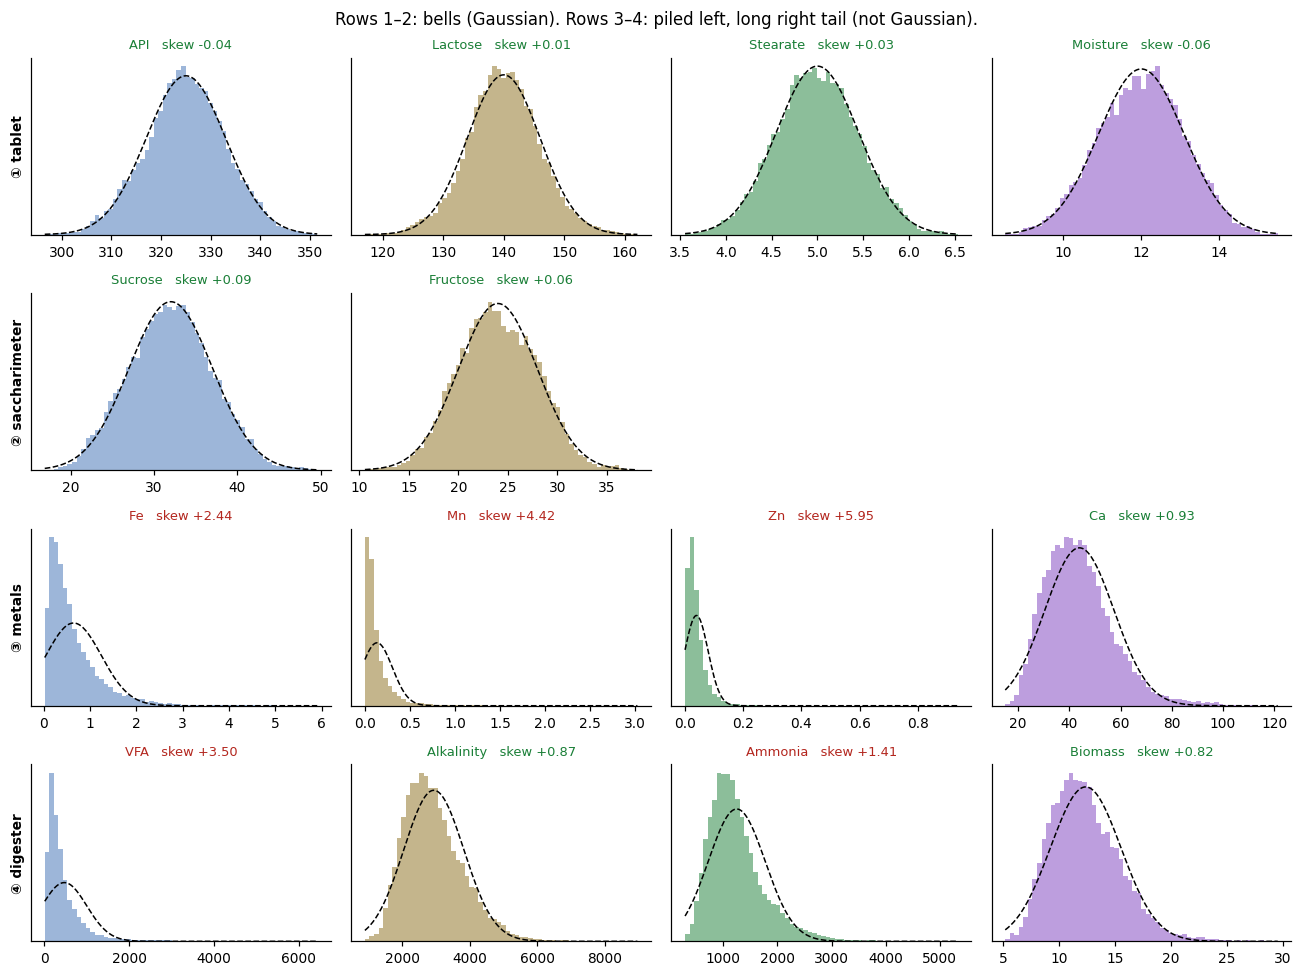

In [13]:
from scipy.stats import norm
fig, axes = plt.subplots(4, 4, figsize=(12, 9))
for r, k in enumerate(KEYS):
    drv = SIMS[k][0]; s = SYS[k]
    for c in range(4):
        ax = axes[r, c]
        if c >= len(s["drv"]):
            ax.axis("off"); continue
        d = s["drv"][c]; y = drv[d]
        ax.hist(y, bins=60, density=True, alpha=.5,
                color=[BLUE, MID, GREEN, "#7d3fbf"][c])
        xs = np.linspace(y.min(), y.max(), 200)
        ax.plot(xs, norm.pdf(xs, y.mean(), y.std()), "k--", lw=1)
        sk = RES[k]["gauss"][d]["skew"]
        ax.set_title(f"{d}   skew {sk:+.2f}", fontsize=8.5,
                     color=(RED if abs(sk) > 1 else GREEN))
        ax.set_yticks([])
    axes[r, 0].set_ylabel(["① tablet", "② saccharimeter", "③ metals", "④ digester"][r],
                          fontsize=9, fontweight="bold")
fig.suptitle("Rows 1–2: bells (Gaussian). Rows 3–4: piled left, long right tail (not Gaussian).")
fig.tight_layout(); plt.show()

## 5 · Inside system ② — training the encoder that can bend

Both linear readers scored ≈ 0 on the saccharimeter. Now we give LeJEPA its real form: a
small neural network (10 → 112 → 112 → 2, tanh), trained in plain NumPy with hand-written
gradients, under exactly the two rules — **alignment** (consecutive moments land close) and
the **round-cloud constraint** (unit variance, decorrelated). The true concentrations are
never shown. As a *ceiling*, we also train a supervised read-out that **is** shown them: if
even that fails, the information was never in the sensors.

*(This cell is the slow one — a few minutes on CPU.)*

In [14]:
from numpy.linalg import lstsq, svd
N, NTR, DZ, D = 24000, 18000, 2, 10
LR, STEPS, H = 0.01, 3200, 112

def probe(R, Y):
    A = np.c_[R[:NTR], np.ones(NTR)]
    c, *_ = lstsq(A, Y[:NTR], rcond=None)
    P = np.c_[R[NTR:], np.ones(N - NTR)] @ c
    return np.array([1 - ((Y[NTR:, j] - P[:, j]) ** 2).sum() /
                     ((Y[NTR:, j] - Y[NTR:, j].mean()) ** 2).sum()
                     for j in range(DZ)])

def lejepa_rep(Xs, seed=1):
    rng = np.random.RandomState(seed)
    P = {"W1": rng.randn(D, H) * np.sqrt(1 / D), "b1": np.zeros(H),
         "W2": rng.randn(H, H) * np.sqrt(1 / H), "b2": np.zeros(H),
         "W3": rng.randn(H, DZ) * np.sqrt(1 / H), "b3": np.zeros(DZ)}
    M = {k: np.zeros_like(v) for k, v in P.items()}
    Vd = {k: np.zeros_like(v) for k, v in P.items()}
    Xtr = Xs[:NTR]; n = NTR; b1, b2, eps = 0.9, 0.999, 1e-8
    for st in range(1, STEPS + 1):
        a1 = np.tanh(Xtr @ P["W1"] + P["b1"])
        a2 = np.tanh(a1 @ P["W2"] + P["b2"])
        E = a2 @ P["W3"] + P["b3"]; Ec = E - E.mean(0)
        Dd = E[:-1] - E[1:]; Gal = np.zeros_like(E)
        Gal[:-1] += 2 * Dd / (n - 1); Gal[1:] -= 2 * Dd / (n - 1)
        sig = np.sqrt(Ec.var(0) + 1e-6)
        Gvar = (-2 * np.maximum(0, 1 - sig) / (n * sig)) * Ec
        Cov = (Ec.T @ Ec) / (n - 1); Mo = Cov.copy(); np.fill_diagonal(Mo, 0)
        Gcov = (4 / (n - 1)) * (Ec @ Mo)
        dE = Gal + Gvar + Gcov
        dW3 = a2.T @ dE; db3 = dE.sum(0); da2 = dE @ P["W3"].T
        dz2 = da2 * (1 - a2 ** 2)
        dW2 = a1.T @ dz2; db2 = dz2.sum(0); da1 = dz2 @ P["W2"].T
        dz1 = da1 * (1 - a1 ** 2)
        dW1 = Xtr.T @ dz1; db1 = dz1.sum(0)
        G = {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2, "W3": dW3, "b3": db3}
        for k in P:
            M[k] = b1 * M[k] + (1 - b1) * G[k]
            Vd[k] = b2 * Vd[k] + (1 - b2) * G[k] ** 2
            P[k] -= LR * (M[k] / (1 - b1 ** st)) / (
                np.sqrt(Vd[k] / (1 - b2 ** st)) + eps)
    a1 = np.tanh(Xs @ P["W1"] + P["b1"])
    a2 = np.tanh(a1 @ P["W2"] + P["b2"])
    return a2 @ P["W3"] + P["b3"]

def align(R, Z):
    Rc = R - R.mean(0); Zc = Z - Z.mean(0)
    Rc /= Rc.std(0); Zc /= Zc.std(0)
    U, _, Vt = svd(Rc.T @ Zc)
    return Rc @ (U @ Vt)

In [15]:
from sklearn.neural_network import MLPRegressor
from numpy.linalg import eigh

drv, clean, noise, noisy, target = SIMS["S2_saccharimeter"]
chan = SYS["S2_saccharimeter"]["chan"]
X  = np.column_stack([noisy[c] for c in chan])
Z  = np.column_stack([drv["Sucrose"], drv["Fructose"]])
Xs = (X - X[:NTR].mean(0)) / X[:NTR].std(0)

C = np.cov(Xs[:NTR].T); w, V = eigh(C); o = np.argsort(w)[::-1]
pca = Xs @ V[:, o[:DZ]]
print("training the LeJEPA encoder (3200 steps of full-batch Adam)...")
lej = lejepa_rep(Xs, seed=1)
sup = MLPRegressor(hidden_layer_sizes=(96, 96), max_iter=2500,
                   random_state=0).fit(Xs[:NTR], Z[:NTR]).predict(Xs)
rp, rl, rs = probe(pca, Z), probe(lej, Z), probe(sup, Z)
print(f"PCA {rp.min():.3f}   supervised ceiling {rs.min():.3f}   LeJEPA {rl.min():.3f}")

training the LeJEPA encoder (3200 steps of full-batch Adam)...


PCA -0.093   supervised ceiling 0.990   LeJEPA 0.975


### The four-panel picture

Every dot is one moment, coloured by where the **true** pair of concentrations sits on a
colour wheel — so the truth is a smooth pinwheel. Watch what each space does to that wheel.
The reconstructions are first rotated onto the truth (orthogonal Procrustes), because a
rotation is exactly what the theorem allows.

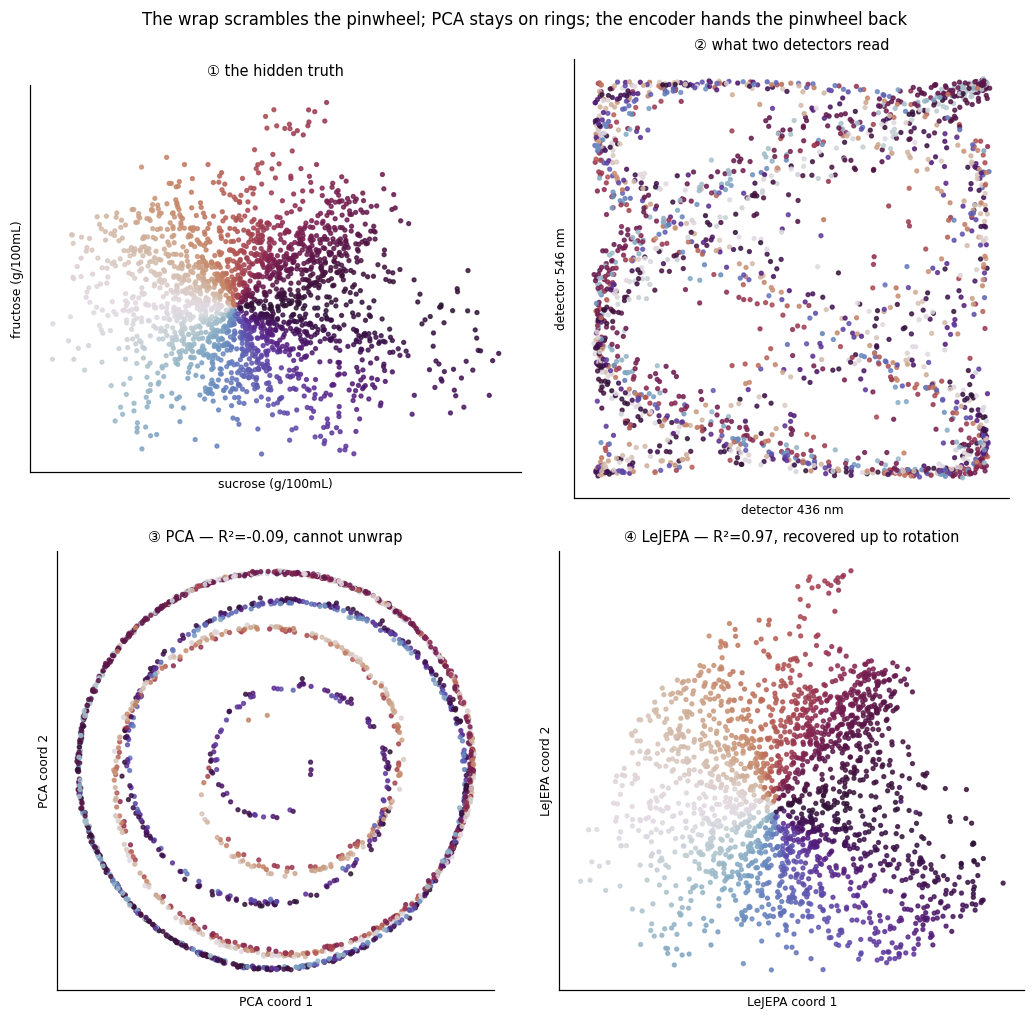

In [16]:
idx = np.arange(NTR, N)[::3]
ang = np.arctan2(Z[idx, 1] - Z[:, 1].mean(), Z[idx, 0] - Z[:, 0].mean())
panels = [("① the hidden truth", Z[idx],
           "sucrose (g/100mL)", "fructose (g/100mL)"),
          ("② what two detectors read", np.column_stack([Xs[idx, 0], Xs[idx, 2]]),
           "detector 436 nm", "detector 546 nm"),
          (f"③ PCA — R²={rp.min():.2f}, cannot unwrap", align(pca, Z)[idx],
           "PCA coord 1", "PCA coord 2"),
          (f"④ LeJEPA — R²={rl.min():.2f}, recovered up to rotation", align(lej, Z)[idx],
           "LeJEPA coord 1", "LeJEPA coord 2")]
fig, axes = plt.subplots(2, 2, figsize=(9.6, 9.4))
fig.subplots_adjust(wspace=0.30, hspace=0.34)
for ax, (t, P, xl, yl) in zip(axes.ravel(), panels):
    ax.scatter(P[:, 0], P[:, 1], c=ang, s=6, cmap="twilight", alpha=.8)
    ax.set_title(t, fontsize=9.5); ax.set_xlabel(xl, fontsize=8); ax.set_ylabel(yl, fontsize=8)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_aspect("equal", "box")
fig.suptitle("The wrap scrambles the pinwheel; PCA stays on rings; the encoder hands the pinwheel back")
fig.tight_layout(); plt.show()

### Strictly up to a rotation?

The linear probe allows any linear map. The theorem promises more: recovery under an
**orthogonal** map only. Test it with Procrustes — fit the single best rotation/reflection
`Q` on training data, apply it, and score on held-out data. If `QᵀQ = I` and the R² stays,
the recovery is genuinely a turned copy of the truth.

In [17]:
from numpy.linalg import svd
def r2_orthogonal(Rrep, Y):
    Rs = (Rrep - Rrep[:NTR].mean(0)) / Rrep[:NTR].std(0)
    Ys = (Y - Y[:NTR].mean(0)) / Y[:NTR].std(0)
    U, _, Vt = svd(Rs[:NTR].T @ Ys[:NTR]); Q = U @ Vt
    P = Rs @ Q
    r2 = [1 - ((Ys[NTR:, j] - P[NTR:, j])**2).sum() / (Ys[NTR:, j]**2).sum()
          for j in range(Y.shape[1])]
    return np.array(r2), Q

ro, Q = r2_orthogonal(lej, Z)
print("orthogonal-only recovery, worst driver: R² = %.3f" % ro.min())
print("Q =", np.round(Q, 3).tolist(), "   QᵀQ =", np.round(Q.T @ Q, 3).tolist())

orthogonal-only recovery, worst driver: R² = 0.977
Q = [[-0.931, -0.364], [-0.364, 0.931]]    QᵀQ = [[1.0, -0.0], [-0.0, 1.0]]


## 6 · When does a plain transform rescue PCA?

“Nonlinear” is not one thing. A **monotone** curve (exponential, saturation, low-order
polynomial) is either straightened by a fixed transform or barely hurts, because we score up
to a linear map. What no fixed transform fixes is a **fold** — and a *single* folded sensor
destroys information outright (even the supervised ceiling fails), while a fold spread
across many sensors (the saccharimeter) keeps the information but hides it from every
straight line.

sensor law                              PCA raw  after transform
Beer-Lambert A=0.20c (linear)              1.00             1.00
Michaelis I=8c/(4+c) (monotone)            0.96             0.96
exponential (monotone)                     0.61             1.00
squared J=(c-5)^2 (a fold)                -0.00            -0.00


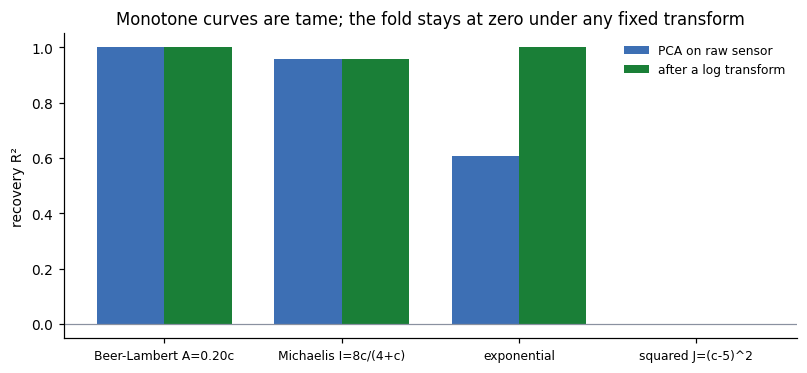

In [18]:
rng = np.random.RandomState(0)
n, ntr = 30000, 20000
cc = np.clip(5.0 + 1.2 * rng.randn(n), 0.05, None)          # a hidden concentration

def r2_lin(x, y):
    A = np.c_[np.atleast_2d(x).T if np.ndim(x) == 1 else x, np.ones(n)][:, :]
    b, *_ = np.linalg.lstsq(A[:ntr], y[:ntr], rcond=None)
    p = A[ntr:] @ b
    return 1 - ((y[ntr:] - p)**2).sum() / ((y[ntr:] - y[ntr:].mean())**2).sum()

cases = [("Beer-Lambert A=0.20c (linear)",      0.20 * cc,            None),
         ("Michaelis I=8c/(4+c) (monotone)",    8 * cc / (4 + cc),    None),
         ("exponential (monotone)",             np.exp(0.8 * (cc - 5)), "log"),
         ("squared J=(c-5)^2 (a fold)",         (cc - 5.0)**2,        "log|x|")]
print(f"{'sensor law':38s} {'PCA raw':>8s} {'after transform':>16s}")
labels, raw, fixed = [], [], []
for name, x, fix in cases:
    r_raw = r2_lin(x, cc)
    r_fix = r2_lin(np.log(np.abs(x) + 1e-9), cc) if fix else r_raw
    print(f"{name:38s} {r_raw:8.2f} {r_fix:16.2f}")
    labels.append(name.split(' (')[0]); raw.append(r_raw); fixed.append(r_fix)

xpos = np.arange(len(labels)); wdt = .38
fig, ax = plt.subplots(figsize=(8.6, 3.6))
ax.bar(xpos - wdt/2, raw,   wdt, color=BLUE,  label="PCA on raw sensor")
ax.bar(xpos + wdt/2, fixed, wdt, color=GREEN, label="after a log transform")
ax.axhline(0, color=GREY, lw=.8)
ax.set_xticks(xpos); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("recovery R²"); ax.legend(frameon=False, fontsize=8)
ax.set_title("Monotone curves are tame; the fold stays at zero under any fixed transform")
plt.show()

The fold's information is *gone* from one squared sensor — no method recovers it. Spread the
fold over ten wrapped detectors instead (system ②) and the information survives but hides
from every straight line: that is the one regime where the trained encoder is not a luxury
but the only reader that works — exactly where the paper's theorem says it should be.

---
**Where the guarantees live:** *When Does LeJEPA Learn a World Model?* — Klindt, LeCun &
Balestriero, [arXiv:2605.26379](https://arxiv.org/abs/2605.26379). This notebook's honest
scope: simulated systems, a compact encoder (not full SIGReg), linear-probe scores with the
orthogonal check run for system ②.